# SkateFormer sweep okna przesuwnego (W, S) na PKU-MMD

Ablacja szerokości okna W i kroku S dla detekcji w trybie ciągłym (Etap III),
w obu protokołach: Cross-Subject i Cross-View

`MIN_SEG_LEN=8`, NMS IoU=0,3 (tylko ta sama klasa, per sekwencja),
AP z interpolacją all-points (VOC2010+), `CONF_TH=0` (sweep progu nie poprawiał mAP).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!git clone -q https://github.com/KAIST-VICLab/SkateFormer.git /content/SkateFormer
print('Repozytorium sklonowane.')

Mounted at /content/drive
Repozytorium sklonowane.


In [3]:
!pip install -q einops timm tensorpack torchpack loguru msgpack msgpack-numpy tabulate tensorboardX
import os, sys
os.chdir('/content/SkateFormer')

#Poprawka torchlight
with open('/content/SkateFormer/torchlight/torchlight/__init__.py', 'w') as f:
    f.write('''import argparse

class DictAction(argparse.Action):
    def __call__(self, parser, namespace, values, option_string=None):
        input_dict = getattr(namespace, self.dest, {}) or {}
        for kv in values:
            key, val = kv.split("=", 1)
            try:
                val = eval(val)
            except:
                pass
            input_dict[key] = val
        setattr(namespace, self.dest, input_dict)

class IO:
    pass
''')
print('Zastosowano poprawkę torchlight.')

#Usunięcie konfliktu z zainstalowaną wersją torchlight
os.system('pip uninstall torchlight -y')
if 'torchlight' in sys.modules:
    del sys.modules['torchlight']
sys.path.insert(0, '/content/SkateFormer/torchlight')
print('Usunięto konflikt z systemowym torchlight.')

#Poprawka main.py
with open('/content/SkateFormer/main.py', 'r') as f:
    content = f.read()
content = content.replace(
    'from torchlight import DictAction',
    '''class DictAction(argparse.Action):
    def __call__(self, parser, namespace, values, option_string=None):
        input_dict = getattr(namespace, self.dest, {}) or {}
        for kv in values:
            key, val = kv.split("=", 1)
            try:
                val = eval(val)
            except:
                pass
            input_dict[key] = val
        setattr(namespace, self.dest, input_dict)'''
)
content = content.replace('default_arg = yaml.load(f)',
                          'default_arg = yaml.load(f, Loader=yaml.SafeLoader)')
with open('/content/SkateFormer/main.py', 'w') as f:
    f.write(content)
print('Zastosowano poprawkę main.py.')

#Zastąpienie przestarzałego np.int
with open('/content/SkateFormer/feeders/feeder_ntu.py', 'r') as f:
    content = f.read()
content = content.replace('.astype(np.int)', '.astype(int)')
with open('/content/SkateFormer/feeders/feeder_ntu.py', 'w') as f:
    f.write(content)
print('Zastąpiono przestarzały typ np.int.')

#Zastąpienie przestarzałych typów NumPy
with open('/content/SkateFormer/feeders/tools.py', 'r') as f:
    content = f.read()
for old, new in [('np.int)', 'int)'), ('np.int,', 'int,'),
                 ('np.float)', 'float)'), ('np.float,', 'float,'),
                 ('np.bool)', 'bool)'), ('np.complex)', 'complex)')]:
    content = content.replace(old, new)
with open('/content/SkateFormer/feeders/tools.py', 'w') as f:
    f.write(content)
print('Zastąpiono przestarzałe typy NumPy.')

print('\nZakończono dostosowanie kodu SkateFormer.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.3/296.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.2 MB/s eta 0:00:00
Zastosowano poprawkę torchlight.
Usunięto konflikt z systemowym torchlight.
Zastosowano poprawkę main.py.
Zastąpiono przestarzały typ np.int.
Zastąpiono przestarzałe typy NumPy.

Zakończono dostosowanie kodu SkateFormer.


In [5]:
-import os, json, shutil
import numpy as np

DRIVE_ROOT    = '/content/drive/MyDrive/PKU_data'
DRIVE_WEIGHTS = '/content/drive/MyDrive/SkateFormer_weights/ntu60_CSub/SkateFormer_j.pt'
LOCAL_DATA    = '/content/SkateFormer/data/ntu'
LOCAL_WEIGHTS = '/content/SkateFormer/SkateFormer_j.pt'
OFFICIAL_CFG  = '/content/SkateFormer/config/test/ntu_cs/SkateFormer_j.yaml'
WORK_DIR_ROOT = '/content/SkateFormer/work_dir/pku_sweep'

SPLIT_DIRS = {'xsub': f'{DRIVE_ROOT}/sweep', 'xview': f'{DRIVE_ROOT}/sweep_xview'}
SPLITS = ['xsub', 'xview']

os.makedirs(LOCAL_DATA, exist_ok=True)
os.makedirs(WORK_DIR_ROOT, exist_ok=True)

shutil.copy(DRIVE_WEIGHTS, LOCAL_WEIGHTS)
print(f'Wagi: {os.path.getsize(LOCAL_WEIGHTS)/1024**2:.1f} MB')

# Faza W (S = W/4) oraz faza S (przy W_BEST)
SWEEP_W = [(32, 8), (64, 16), (96, 24), (128, 32)]
W_BEST  = 64
SWEEP_S = [(W_BEST, 8), (W_BEST, 32)]

seen, CONFIGS = set(), []
for w, s in SWEEP_W + SWEEP_S:
    if (w, s) not in seen:
        seen.add((w, s)); CONFIGS.append((w, s))
print('Configi:', CONFIGS)

GT, SEQ_LEN = {}, {}
for sp in SPLITS:
    d = SPLIT_DIRS[sp]
    if not os.path.exists(f'{d}/ground_truth.json'):
        print(f'{sp.upper()}: BRAK danych w {d}')
        continue
    with open(f'{d}/ground_truth.json') as f:
        GT[sp] = json.load(f)
    with open(f'{d}/seq_lengths.json') as f:
        SEQ_LEN[sp] = json.load(f)

    n_remap = 0
    for sid in GT[sp]:
        for inst in GT[sp][sid]:
            if inst[0] == 56:
                inst[0] = 24; n_remap += 1
    n_seg = sum(len(v) for v in GT[sp].values())
    print(f'{sp.upper()}: {len(GT[sp])} sekwencji, {n_seg} segmentow GT, remap 56->24: {n_remap}')

SPLITS = [sp for sp in SPLITS if sp in GT]
print('')
print('Protokoly do policzenia:', SPLITS)

Wagi: 13.9 MB
Configi: [(32, 8), (64, 16), (96, 24), (128, 32), (64, 8), (64, 32)]
XSUB: 132 sekwencji, 2696 segmentow GT, remap 56->24: 143
XVIEW: 359 sekwencji, 7141 segmentow GT, remap 56->24: 308

Protokoly do policzenia: ['xsub', 'xview']


In [7]:
import pickle, yaml

def run_inference(split, W, S, force=False):
    drive_sweep = SPLIT_DIRS[split]
    src_npz  = f'{drive_sweep}/PKU_windows_test_W{W}_S{S}.npz'
    dst_npz  = f'{LOCAL_DATA}/PKU_win_buf_{split}_W{W}_S{S}.npz'
    work_dir = f'{WORK_DIR_ROOT}/{split}_W{W}_S{S}'
    cache_dir = f'{drive_sweep}/scores/W{W}_S{S}'
    os.makedirs(work_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    data = np.load(src_npz)
    n = data['x_test'].shape[0]

    meta = {'seq_id': data['seq_id'], 'start': data['start'],
            'end': data['end'], 'y_ref': data['y_ref']}

    if not os.listdir(work_dir) and os.listdir(cache_dir):
        for f_ in os.listdir(cache_dir):
            shutil.copy(f'{cache_dir}/{f_}', f'{work_dir}/{f_}')
        print('Przywrocono score.pkl z Drive')

    existing = [p for p in os.listdir(work_dir) if p.endswith('score.pkl')]
    if existing and not force:
        print('Cache: pomijam inferencje')
    else:
        #Jedna dodatkowa klatka jest potrzebna przez indeksowanie w feederze.
        #Bufor tworzę osobno, żeby ograniczyć zużycie pamięci.
        x_buf = np.zeros((n, W + 1, 150), dtype=np.float32)
        x_buf[:, :W, :] = data['x_test']
        y_test = data['y_test']
        del data
        import gc; gc.collect()
        np.savez(dst_npz, x_test=x_buf, y_test=y_test)
        print(f'  Bufor: (N, {W}, 150) -> {x_buf.shape}')
        del x_buf; gc.collect()

        with open(OFFICIAL_CFG) as f:
            cfg = yaml.safe_load(f)
        cfg['work_dir']   = work_dir
        cfg['weights']    = LOCAL_WEIGHTS
        cfg['phase']      = 'test'
        cfg['save_score'] = True
        cfg['test_feeder_args']['data_path'] = dst_npz
        cfg['test_feeder_args']['split']     = 'test'
        cfg_path = f'{work_dir}/config.yaml'
        with open(cfg_path, 'w') as f:
            yaml.dump(cfg, f)

        !cd /content/SkateFormer && python main.py --config "{cfg_path}"

        existing = [p for p in os.listdir(work_dir) if p.endswith('score.pkl')]
        assert existing, f'Brak score.pkl w {work_dir} — main.py sie wywalil?'
        shutil.copy(f'{work_dir}/{existing[0]}', f'{cache_dir}/{existing[0]}')
        os.remove(dst_npz)

    with open(f'{work_dir}/{existing[0]}', 'rb') as f:
        scores = pickle.load(f)
    assert len(scores) == n, f'{len(scores)} wynikow vs {n} okien!'
    logits = np.array([scores[f'test_{i}'] for i in range(n)])
    return logits, meta

print('run_inference gotowe.')

run_inference gotowe.


 agregacja softmaxu per klatka, scalanie sąsiednich klatek o tej samej
predykcji w segmenty (min. 8 klatek), NMS temporalny, AP per klasa, mAP.

In [11]:
from collections import defaultdict

INTERACTION_NTU = [49, 50, 51, 52, 53, 54, 55, 57]
MIN_SEG_LEN = 8
NMS_IOU = 0.3
CONF_TH = 0.0

def build_frame_level(logits, meta, seq_lengths, conf_th=CONF_TH):
    p = np.exp(logits - logits.max(axis=1, keepdims=True))
    p /= p.sum(axis=1, keepdims=True)
    fp = {s: np.zeros((T, 60)) for s, T in seq_lengths.items()}
    fc = {s: np.zeros(T) for s, T in seq_lengths.items()}
    for i in range(len(meta['seq_id'])):
        s = str(meta['seq_id'][i])
        st, en = int(meta['start'][i]), int(meta['end'][i])
        fp[s][st:en] += p[i]; fc[s][st:en] += 1
    pred, avg_all = {}, {}
    for s, T in seq_lengths.items():
        avg = fp[s] / np.maximum(fc[s], 1)[:, None]
        pr = np.argmax(avg, 1); cf = np.max(avg, 1)
        pr[cf < conf_th] = -1
        pr[fc[s] == 0] = -1
        pred[s] = pr; avg_all[s] = avg
    return pred, avg_all, fc

def frames_to_segments(pred, prob_avg):
    segs = []; T = len(pred); t = 0
    while t < T:
        c = pred[t]
        if c < 0:
            t += 1; continue
        st = t
        while t < T and pred[t] == c:
            t += 1
        if t - st >= MIN_SEG_LEN:
            segs.append((int(c), st, t, float(prob_avg[st:t, c].mean())))
    return segs

def iou_1d(a, b):
    s = max(a[0], b[0]); e = min(a[1], b[1]); inter = max(0, e - s)
    u = (a[1] - a[0]) + (b[1] - b[0]) - inter
    return inter / u if u > 0 else 0.0

def nms_segments(segs, iou_th=NMS_IOU):
    segs = sorted(segs, key=lambda x: x[3], reverse=True); keep = []
    while segs:
        b = segs.pop(0); keep.append(b)
        segs = [x for x in segs
                if not (x[0] == b[0] and iou_1d((x[1], x[2]), (b[1], b[2])) > iou_th)]
    return keep

def compute_ap(pred_list, gt_list, iou_th):
    if len(gt_list) == 0:
        return None
    preds = sorted(pred_list, key=lambda x: x[3], reverse=True); matched = set(); tp = np.zeros(len(preds)); fp_ = np.zeros(len(preds))
    for i, (seq, st, en, sc) in enumerate(preds):
        bi, bj = 0, -1
        for j, (gs, gst, gen) in enumerate(gt_list):
            if gs != seq or (seq, j) in matched:
                continue
            v = iou_1d((st, en), (gst, gen))
            if v > bi:
                bi, bj = v, j
        if bi >= iou_th:
            tp[i] = 1; matched.add((seq, bj))
        else:
            fp_[i] = 1
    tpc = np.cumsum(tp); fpc = np.cumsum(fp_)
    rec = tpc / len(gt_list); prec = tpc / np.maximum(tpc + fpc, 1e-9)
    mrec = np.concatenate([[0], rec, [1]]); mpre = np.concatenate([[0], prec, [0]])
    for k in range(len(mpre) - 2, -1, -1):
        mpre[k] = max(mpre[k], mpre[k + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

def evaluate(logits, meta, seq_lengths, gt_segments, conf_th=CONF_TH,
             iou_list=(0.1, 0.3, 0.5), classes=None):
    pred, avg_all, fc = build_frame_level(logits, meta, seq_lengths, conf_th)
    pred_by_cls = defaultdict(list)
    for s in seq_lengths:
        for (c, st, en, sc) in nms_segments(frames_to_segments(pred[s], avg_all[s])):
            pred_by_cls[c].append((s, st, en, sc))
    gt_by_cls = defaultdict(list)
    for s, segs in gt_segments.items():
        T = seq_lengths[s]
        for (c, st, en) in segs:
            st, en = max(0, st), min(T, en)
            if en > st:
                gt_by_cls[c].append((s, st, en))
    if classes is not None:
        gt_by_cls = {c: v for c, v in gt_by_cls.items() if c in classes}
    results = {}
    for iou in iou_list:
        aps = {}
        for c in gt_by_cls:
            ap = compute_ap(pred_by_cls.get(c, []), gt_by_cls[c], iou)
            if ap is not None:
                aps[c] = ap
        results[iou] = {'mAP': float(np.mean(list(aps.values()))) if aps else 0.0,
                        'per_class': aps}
    return results, pred_by_cls, gt_by_cls

def frame_level_accuracy(logits, meta, seq_lengths, gt_segments,
                         conf_th=CONF_TH, classes=None):
    pred, _, _ = build_frame_level(logits, meta, seq_lengths, conf_th)
    ca = ta = 0
    for s, T in seq_lengths.items():
        g = -np.ones(T, int)
        for (c, st, en) in gt_segments[s]:
            if classes is not None and c not in classes:
                continue
            g[max(0, st):min(T, en)] = c
        mk = g >= 0; p = pred[s]
        ca += (p[mk] == g[mk]).sum(); ta += mk.sum()
    return ca / ta if ta else 0.0

print('Funkcje detekcji gotowe (MIN_SEG_LEN=8, NMS IoU=0.3, AP all-points).')

Funkcje detekcji gotowe (MIN_SEG_LEN=8, NMS IoU=0.3, AP all-points).


In [ ]:
results = []
for split in SPLITS:
    gt, seq_len = GT[split], SEQ_LEN[split]
    for W, S in CONFIGS:
        npz = f'{SPLIT_DIRS[split]}/PKU_windows_test_W{W}_S{S}.npz'
        if not os.path.exists(npz):
            print(f'  [{split.upper()}] W={W} S={S}: brak pliku')
            continue
        print(f'\n=== [{split.upper()}] W={W} S={S} ===')
        logits, meta = run_inference(split, W, S)

        res, pred_by_cls, _ = evaluate(logits, meta, seq_len, gt)
        facc = frame_level_accuracy(logits, meta, seq_len, gt)
        res_i, _, _ = evaluate(logits, meta, seq_len, gt, classes=INTERACTION_NTU)
        facc_i = frame_level_accuracy(logits, meta, seq_len, gt,
                                      classes=INTERACTION_NTU)

        row = {'split': split, 'W': W, 'S': S, 'n_windows': len(logits),
               'n_detekcji': sum(len(v) for v in pred_by_cls.values()),
               'frame_acc': facc,
               'mAP@0.1': res[0.1]['mAP'], 'mAP@0.3': res[0.3]['mAP'],
               'mAP@0.5': res[0.5]['mAP'],
               'frame_acc_inter': facc_i,
               'mAP@0.1_inter': res_i[0.1]['mAP'], 'mAP@0.3_inter': res_i[0.3]['mAP'],
               'mAP@0.5_inter': res_i[0.5]['mAP']}
        results.append(row)
        print(f"  wszystkie: frame={facc*100:.2f}%  mAP@0,1={res[0.1]['mAP']*100:.2f}%  "
              f"mAP@0,3={res[0.3]['mAP']*100:.2f}%  mAP@0,5={res[0.5]['mAP']*100:.2f}%")
        print(f"  interakcje: frame={facc_i*100:.2f}%  mAP@0,1={res_i[0.1]['mAP']*100:.2f}%  "
              f"mAP@0,3={res_i[0.3]['mAP']*100:.2f}%  mAP@0,5={res_i[0.5]['mAP']*100:.2f}%")

        #zwolnienie pamieci
        del logits, meta, res, res_i, pred_by_cls
        import gc; gc.collect()


=== [XSUB] W=32 S=8 ===
  Przywrocono score.pkl z Drive
  Cache: pomijam inferencje
  wszystkie: frame=34.63%  mAP@0,1=58.07%  mAP@0,3=43.03%  mAP@0,5=25.56%
  interakcje: frame=57.81%  mAP@0,1=72.72%  mAP@0,3=57.34%  mAP@0,5=33.44%

=== [XSUB] W=64 S=16 ===
  Przywrocono score.pkl z Drive
  Cache: pomijam inferencje
  wszystkie: frame=55.57%  mAP@0,1=73.04%  mAP@0,3=63.06%  mAP@0,5=44.32%
  interakcje: frame=70.87%  mAP@0,1=69.40%  mAP@0,3=57.44%  mAP@0,5=40.49%

=== [XSUB] W=96 S=24 ===
  Przywrocono score.pkl z Drive
  Cache: pomijam inferencje
  wszystkie: frame=59.19%  mAP@0,1=67.63%  mAP@0,3=57.42%  mAP@0,5=36.45%
  interakcje: frame=70.59%  mAP@0,1=60.32%  mAP@0,3=47.51%  mAP@0,5=27.26%

=== [XSUB] W=128 S=32 ===
  Przywrocono score.pkl z Drive
  Cache: pomijam inferencje
  wszystkie: frame=53.52%  mAP@0,1=54.79%  mAP@0,3=43.53%  mAP@0,5=24.69%
  interakcje: frame=60.65%  mAP@0,1=45.19%  mAP@0,3=30.56%  mAP@0,5=18.75%

=== [XSUB] W=64 S=8 ===
  Przywrocono score.pkl z Drive
  C

In [ ]:
KANON = {'mAP@0.1': 71.2, 'mAP@0.3': 62.9, 'mAP@0.5': 43.4, 'frame_acc': 54.1,
         'mAP@0.3_inter': 58.2}

ref = next((r for r in results
            if r['split'] == 'xsub' and r['W'] == 64 and r['S'] == 16), None)
if ref is None:
    print('Brak wyniku XSub dla W=64/S=16')
else:
    print('Kontrola: XSub, W=64, S=16 (kanon = rozdzial 4.3 pracy)\n')
    print(f'{"Metryka":<14}{"Kanon":>9}{"Sweep":>9}{"Delta":>9}')
    print('-' * 41)
    for k, v in KANON.items():
        got = ref[k] * 100
        flag = 'OK' if abs(got - v) < 2.0 else '<-- sprawdz'
        print(f'{k:<14}{v:>9.1f}{got:>9.2f}{got - v:>+9.2f}  {flag}')

Kontrola: XSub, W=64, S=16 (kanon = rozdzial 4.3 pracy)

Metryka           Kanon    Sweep    Delta
-----------------------------------------
mAP@0.1            71.2    73.04    +1.84  OK
mAP@0.3            62.9    63.06    +0.16  OK
mAP@0.5            43.4    44.32    +0.92  OK
frame_acc          54.1    55.57    +1.47  OK
mAP@0.3_inter      58.2    57.44    -0.76  OK


## KROK 7 — Tabela wyników

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
pct = ['frame_acc', 'mAP@0.1', 'mAP@0.3', 'mAP@0.5',
       'frame_acc_inter', 'mAP@0.1_inter', 'mAP@0.3_inter', 'mAP@0.5_inter']
for c in pct:
    df[c] = (df[c] * 100).round(2)

for sp in SPLITS:
    d = df[df['split'] == sp]
    print(f'=== {sp.upper()} — wszystkie 51 klas ===')
    display(d[['W', 'S', 'n_windows', 'n_detekcji', 'frame_acc',
               'mAP@0.1', 'mAP@0.3', 'mAP@0.5']].reset_index(drop=True))
    print(f'=== {sp.upper()} — tylko 8 klas interakcji ===')
    display(d[['W', 'S', 'frame_acc_inter', 'mAP@0.1_inter',
               'mAP@0.3_inter', 'mAP@0.5_inter']].reset_index(drop=True))
    print()

=== XSUB — wszystkie 51 klas ===


,W,S,n_windows,n_detekcji,frame_acc,mAP@0.1,mAP@0.3,mAP@0.5
0,32,8,79122,16738,34.63,58.07,43.03,25.56
1,64,16,39401,10602,55.57,73.04,63.06,44.32
2,96,24,26158,7738,59.19,67.63,57.42,36.45
3,128,32,19538,6064,53.52,54.79,43.53,24.69
4,64,8,78600,10939,56.04,73.57,63.95,45.18
5,64,32,19802,9756,53.74,70.17,58.99,35.80


=== XSUB — tylko 8 klas interakcji ===


,W,S,frame_acc_inter,mAP@0.1_inter,mAP@0.3_inter,mAP@0.5_inter
0,32,8,57.81,72.72,57.34,33.44
1,64,16,70.87,69.40,57.44,40.49
2,96,24,70.59,60.32,47.51,27.26
3,128,32,60.65,45.19,30.56,18.75
4,64,8,70.96,71.06,60.45,42.03
5,64,32,66.53,62.82,51.54,29.47



=== XVIEW — wszystkie 51 klas ===


,W,S,n_windows,n_detekcji,frame_acc,mAP@0.1,mAP@0.3,mAP@0.5
0,32,8,227166,46927,36.52,55.79,40.46,24.14
1,64,16,113153,29177,57.69,74.23,64.18,44.09
2,96,24,75147,21094,62.10,69.65,59.93,38.91
3,128,32,56140,16500,57.76,58.79,47.15,26.71
4,64,32,56852,26971,55.90,70.06,58.58,35.95


=== XVIEW — tylko 8 klas interakcji ===


,W,S,frame_acc_inter,mAP@0.1_inter,mAP@0.3_inter,mAP@0.5_inter
0,32,8,60.38,68.84,56.68,29.27
1,64,16,73.59,70.08,61.79,43.59
2,96,24,74.05,61.51,51.35,32.56
3,128,32,64.43,47.33,33.27,20.70
4,64,32,70.91,60.98,51.97,32.46


## KROK 8 — Wykresy

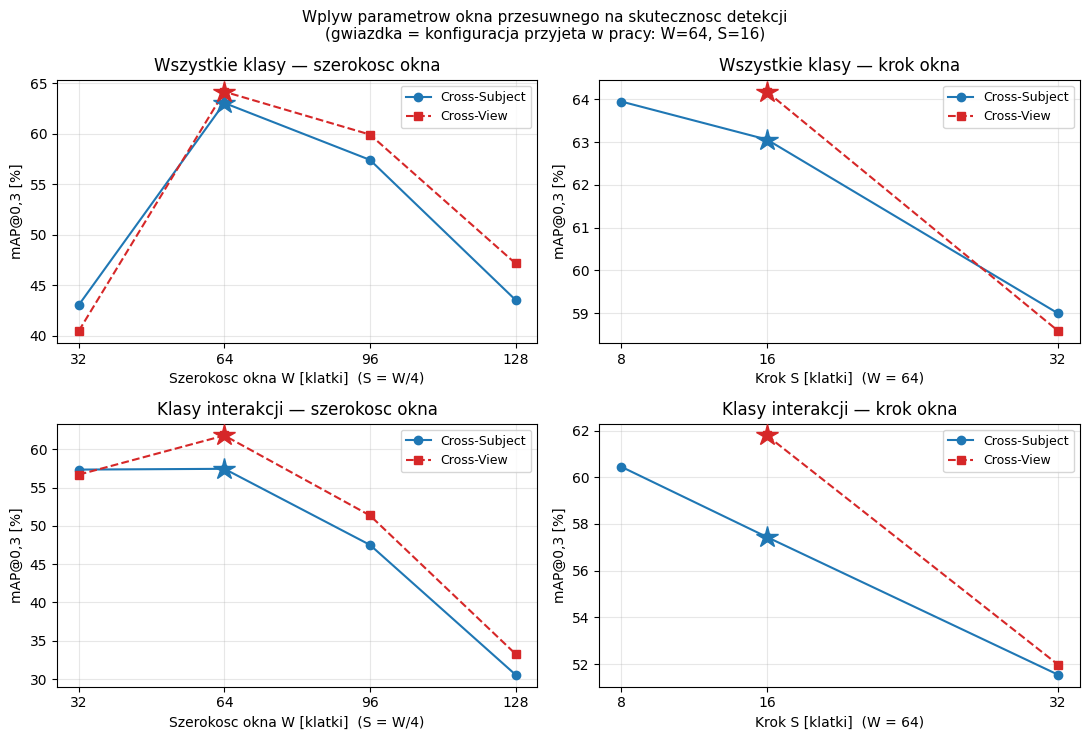

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})
STYLE = {'xsub': dict(color='#1f77b4', marker='o', ls='-', label='Cross-Subject'),
         'xview': dict(color='#d62728', marker='s', ls='--', label='Cross-View')}

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

panels = [
    (0, 0, 'W', 'mAP@0.3',       'Wszystkie klasy - szerokosc okna'),
    (0, 1, 'S', 'mAP@0.3',       'Wszystkie klasy - krok okna'),
    (1, 0, 'W', 'mAP@0.3_inter', 'Klasy interakcji - szerokosc okna'),
    (1, 1, 'S', 'mAP@0.3_inter', 'Klasy interakcji - krok okna'),
]

for r, c, xvar, yvar, title in panels:
    ax = axes[r, c]
    for sp in SPLITS:
        d = df[df['split'] == sp]
        if xvar == 'W':
            sub = d[d.apply(lambda x: (x['W'], x['S']) in set(SWEEP_W), axis=1)]
        else:
            sub = d[d.apply(lambda x: (x['W'], x['S']) in set(SWEEP_S) | {(W_BEST, 16)},
                            axis=1)]
        sub = sub.sort_values(xvar)
        ax.plot(sub[xvar], sub[yvar], ms=6, **STYLE[sp])

        pick = sub[(sub['W'] == 64) & (sub['S'] == 16)]
        if len(pick):
            ax.plot(pick[xvar], pick[yvar], marker='*', ms=16, ls='none',
                    color=STYLE[sp]['color'], zorder=5)
    ax.set_xlabel('Szerokosc okna W [klatki]  (S = W/4)' if xvar == 'W'
                  else f'Krok S [klatki]  (W = {W_BEST})')
    ax.set_ylabel('mAP@0,3 [%]')
    ax.set_title(title)
    ax.set_xticks(sorted(df[df.apply(
        lambda x: (x['W'], x['S']) in (set(SWEEP_W) if xvar == 'W'
                                       else set(SWEEP_S) | {(W_BEST, 16)}), axis=1)][xvar].unique()))
    ax.legend(fontsize=9)

fig.suptitle('Wplyw parametrow okna przesuwnego na skutecznosc detekcji\n'
             '(gwiazdka = konfiguracja przyjeta w pracy: W=64, S=16)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/ablacja_okna.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
NTU_INT_NAMES = {
    49: 'punch/slap', 50: 'kick person', 51: 'push person', 52: 'pat on back',
    53: 'point at person', 54: 'hugging', 55: 'giving object', 57: 'handshaking',
}
ws = [w for w, _ in SWEEP_W]

for split in SPLITS:
    gt, seq_len = GT[split], SEQ_LEN[split]
    per_class = {}
    for W, S in SWEEP_W:
        npz = f'{SPLIT_DIRS[split]}/PKU_windows_test_W{W}_S{S}.npz'
        if not os.path.exists(npz):
            continue
        logits, meta = run_inference(split, W, S)
        res, _, _ = evaluate(logits, meta, seq_len, gt,
                             iou_list=(0.3,), classes=INTERACTION_NTU)
        per_class[W] = res[0.3]['per_class']

    print(f'\n{"="*78}')
    print(f'{split.upper()} — AP@0,3 per klasa interakcji')
    print('='*78)
    hdr = ''.join(f'{f"W={w}":>9}' for w in ws)
    print(f'{"Klasa":<18}{"n":>4}{"sr.dl.":>8}{"std":>7}{"med":>7}{hdr}')
    print('-' * (44 + 9 * len(ws)))

    rows = []
    for c in INTERACTION_NTU:
        lens = np.array([e - s for segs in gt.values()
                         for cls, s, e in segs if cls == c])
        if len(lens) == 0:
            continue
        vals = ''.join(
            f'{per_class[w][c]*100:>9.1f}' if per_class[w].get(c) is not None
            else f'{"—":>9}' for w in ws)
        print(f'{NTU_INT_NAMES[c]:<18}{len(lens):>4}{lens.mean():>8.1f}'
              f'{lens.std():>7.1f}{np.median(lens):>7.1f}{vals}')
        aps = {w: per_class[w].get(c) for w in ws if per_class[w].get(c) is not None}
        if aps:
            rows.append((lens.mean(), max(aps, key=aps.get)))

    if len(rows) > 2:
        r = np.corrcoef([x[0] for x in rows], [x[1] for x in rows])[0, 1]
        print(f'\nKorelacja (sr. dlugosc akcji vs optymalne W): r = {r:+.3f}')
        print('Interpretacja: |r| < 0,3 oznacza brak zwiazku - optymalne W nie wynika')
        print('z czasu trwania akcji. Przy ~24 segmentach GT na klase wybor najlepszego W')
        print('jest w duzej mierze szumem.')

  Cache: pomijam inferencje
  Cache: pomijam inferencje
  Cache: pomijam inferencje
  Cache: pomijam inferencje

XSUB — AP@0,3 per klasa interakcji
Klasa                n  sr.dl.    std    med     W=32     W=64     W=96    W=128
--------------------------------------------------------------------------------
punch/slap          24    56.7   13.4   56.0     35.1     42.2     50.3     16.9
kick person         27    42.0   11.2   40.0     84.7     44.3     34.4     21.6
push person         24    67.4   26.7   56.0     59.3     67.6     41.8     18.0
pat on back         24    69.6    8.9   70.5     20.1      8.8      5.7      3.0
point at person     24    69.4   17.7   73.5      8.4      6.1     10.1      6.8
hugging             24   123.4   17.7  128.5     78.4     95.4     91.7     95.2
giving object       24   111.0   27.1  107.0     72.7     99.5     73.4     56.5
handshaking         24    94.5   13.7   94.0    100.0     95.7     72.7     26.5

Korelacja (sr. dlugosc akcji vs optymalne

## KROK 10 — Zapis wyników

In [ ]:
df.to_csv(f'{DRIVE_ROOT}/sweep_results.csv', index=False)
print('Zapisano na Drive:')
print(f'  {DRIVE_ROOT}/sweep_results.csv')
print(f'  {DRIVE_ROOT}/ablacja_okna.png')
for sp in SPLITS:
    print(f'  {SPLIT_DIRS[sp]}/scores/  (logity — cache)')

Zapisano na Drive:
  /content/drive/MyDrive/PKU_data/sweep_results.csv
  /content/drive/MyDrive/PKU_data/ablacja_okna.png
  /content/drive/MyDrive/PKU_data/sweep/scores/  (logity — cache)
  /content/drive/MyDrive/PKU_data/sweep_xview/scores/  (logity — cache)


In [ ]:
# Diagnostyka: pat on back i point at person, dlaczego detekcja zawodzi
TARGET = {52: 'pat on back', 53: 'point at person'}

for split in SPLITS:
    gt, seq_len = GT[split], SEQ_LEN[split]
    logits, meta = run_inference(split, 64, 16)
    pred, avg_all, fc = build_frame_level(logits, meta, seq_len)

    pred_by_cls = defaultdict(list)
    for s in seq_len:
        for (c, st, en, sc) in nms_segments(frames_to_segments(pred[s], avg_all[s])):
            pred_by_cls[c].append((s, st, en, sc))

    print(f'\n{"="*72}\n{split.upper()} — diagnostyka lokalizacji (W=64, S=16)\n{"="*72}')
    print(f'{"Klasa":<18}{"segm.GT":>8}{"detekcji":>10}{"TP@0.1":>8}{"TP@0.3":>8}'
          f'{"TP@0.5":>8}{"sr.IoU":>8}{"AP@0.3":>8}')
    print('-'*78)

    for c, name in TARGET.items():
        gt_segs = [(s, st, en) for s in gt for cc, st, en in gt[s] if cc == c]
        dets = pred_by_cls.get(c, [])

        ious = []
        tp = {0.1: 0, 0.3: 0, 0.5: 0}
        used = set()
        for (s, st, en, sc) in sorted(dets, key=lambda x: -x[3]):
            best, bj = 0, -1
            for j, (gs, gst, gen) in enumerate(gt_segs):
                if gs != s or (s, j) in used: continue
                v = iou_1d((st, en), (gst, gen))
                if v > best: best, bj = v, j
            ious.append(best)
            for th in tp:
                if best >= th and bj >= 0 and (s, bj, th) not in used:
                    pass
            for th in tp:
                if best >= th: tp[th] += 1

        ap = compute_ap([(s, st, en, sc) for s, st, en, sc in dets], gt_segs, 0.3)
        mean_iou = np.mean(ious) if ious else 0
        print(f'{name:<18}{len(gt_segs):>8}{len(dets):>10}{tp[0.1]:>8}{tp[0.3]:>8}'
              f'{tp[0.5]:>8}{mean_iou:>8.3f}{(ap or 0)*100:>7.1f}%')

    #hugging (dobra klasa)
    for c, name in {54: 'hugging (ref)'}.items():
        gt_segs = [(s, st, en) for s in gt for cc, st, en in gt[s] if cc == c]
        dets = pred_by_cls.get(c, [])
        ious = []
        for (s, st, en, sc) in dets:
            best = max([iou_1d((st,en),(gst,gen)) for gs,gst,gen in gt_segs if gs==s]
                       + [0])
            ious.append(best)
        ap = compute_ap(dets, gt_segs, 0.3)
        print(f'{name:<18}{len(gt_segs):>8}{len(dets):>10}{"":>8}{"":>8}{"":>8}'
              f'{np.mean(ious) if ious else 0:>8.3f}{(ap or 0)*100:>7.1f}%')

  Przywrocono score.pkl z Drive
  Cache: pomijam inferencje

XSUB — diagnostyka lokalizacji (W=64, S=16)
Klasa              segm.GT  detekcji  TP@0.1  TP@0.3  TP@0.5  sr.IoU  AP@0.3
------------------------------------------------------------------------------
pat on back             24       116      15      12       4   0.058    8.8%
point at person         24       814      19      11       8   0.011    6.1%
hugging (ref)           24        29                           0.440   95.4%
  Przywrocono score.pkl z Drive
  Cache: pomijam inferencje

XVIEW — diagnostyka lokalizacji (W=64, S=16)
Klasa              segm.GT  detekcji  TP@0.1  TP@0.3  TP@0.5  sr.IoU  AP@0.3
------------------------------------------------------------------------------
pat on back             71       415      62      49      30   0.076   10.3%
point at person         72      1453      66      46      30   0.022   11.3%
hugging (ref)           71        78                           0.489   92.9%


In [ ]:
# ── Sweep MIN_SEG_LEN: czy odciecie krotkich segmentow poprawia mAP ──
# Przyczyna niskiego AP dla point at person: over-triggering (814 detekcji
# na 24 GT, sr. IoU 0,011). Hipoteza: podniesienie MIN_SEG_LEN wytnie krotkie
# smieci. Ryzyko: za wysoki prog skasuje tez prawdziwe krotkie akcje (kick).
import copy

def evaluate_msl(logits, meta, seq_lengths, gt, min_seg_len, classes=None):
    """evaluate() z parametryzowanym MIN_SEG_LEN (nadpisuje globalny)."""
    global MIN_SEG_LEN
    old = MIN_SEG_LEN
    MIN_SEG_LEN = min_seg_len
    try:
        res, pred_by_cls, _ = evaluate(logits, meta, seq_lengths, gt, classes=classes)
    finally:
        MIN_SEG_LEN = old
    n_det = sum(len(v) for v in pred_by_cls.values())
    return res, n_det

MSL_GRID = [8, 12, 16, 20, 24, 32]
CFG = (64, 16)   # konfiguracja z pracy

msl_results = []
for split in SPLITS:
    gt, seq_len = GT[split], SEQ_LEN[split]
    logits, meta = run_inference(split, *CFG)
    for msl in MSL_GRID:
        res_all, ndet = evaluate_msl(logits, meta, seq_len, gt, msl)
        res_int, _    = evaluate_msl(logits, meta, seq_len, gt, msl,
                                     classes=INTERACTION_NTU)
        # osobno point at person (53) i pat on back (52)
        pt = res_int[0.3]['per_class'].get(53)
        pb = res_int[0.3]['per_class'].get(52)
        msl_results.append({
            'split': split, 'MIN_SEG_LEN': msl, 'n_det': ndet,
            'mAP@0.3': res_all[0.3]['mAP'],
            'mAP@0.3_int': res_int[0.3]['mAP'],
            'point_at': pt, 'pat_back': pb,
        })
    del logits, meta
    import gc; gc.collect()

import pandas as pd
dfm = pd.DataFrame(msl_results)
for c in ['mAP@0.3', 'mAP@0.3_int', 'point_at', 'pat_back']:
    dfm[c] = (dfm[c] * 100).round(2)
for sp in SPLITS:
    print(f'\n=== {sp.upper()} ===')
    print(dfm[dfm.split == sp][['MIN_SEG_LEN', 'n_det', 'mAP@0.3',
                                 'mAP@0.3_int', 'point_at', 'pat_back']].to_string(index=False))

  Cache: pomijam inferencje
  Cache: pomijam inferencje

=== XSUB ===
 MIN_SEG_LEN  n_det  mAP@0.3  mAP@0.3_int  point_at  pat_back
           8  10602    63.06        57.44      6.14      8.81
          12  10596    63.06        57.44      6.14      8.81
          16  10586    63.12        57.47      6.46      8.81
          20   8952    63.16        57.48      6.46      8.81
          24   8947    63.16        57.48      6.46      8.81
          32   8935    63.16        57.48      6.46      8.81

=== XVIEW ===
 MIN_SEG_LEN  n_det  mAP@0.3  mAP@0.3_int  point_at  pat_back
           8  29177    64.18        61.79     11.26     10.35
          12  29151    64.20        61.82     11.32     10.38
          16  29127    64.23        61.98     11.33     10.38
          20  24849    64.40        62.36     11.35     10.40
          24  24843    64.40        62.36     11.35     10.40
          32  24812    64.44        62.38     11.41     10.47


In [ ]:
# ── Naprawa 2: wygladzanie czasowe predykcji per-klatka (majority vote) ──
# Diagnostyka: model przewiduje klatki niezaleznie, wiec predykcje "migocza"
# — pojedyncze klatki point-at wskakuja w srodek innej akcji. Zamiast filtrowac
# gotowe segmenty (MIN_SEG_LEN nie zadzialal), wygladzamy predykcje ZANIM je
# sklejamy: kazda klatka dostaje klase wiekszosciowa z okna +/-k sasiednich.
from scipy import stats as _st

def build_frame_level_smooth(logits, meta, seq_lengths, k, conf_th=CONF_TH):
    """Jak build_frame_level, ale z wygladzaniem predykcji oknem +/-k klatek."""
    p = np.exp(logits - logits.max(axis=1, keepdims=True))
    p /= p.sum(axis=1, keepdims=True)
    fp = {s: np.zeros((T, 60)) for s, T in seq_lengths.items()}
    fc = {s: np.zeros(T) for s, T in seq_lengths.items()}
    for i in range(len(meta['seq_id'])):
        s = str(meta['seq_id'][i])
        st, en = int(meta['start'][i]), int(meta['end'][i])
        fp[s][st:en] += p[i]; fc[s][st:en] += 1
    pred, avg_all = {}, {}
    for s, T in seq_lengths.items():
        avg = fp[s] / np.maximum(fc[s], 1)[:, None]
        pr = np.argmax(avg, 1); cf = np.max(avg, 1)
        pr[cf < conf_th] = -1
        pr[fc[s] == 0] = -1
        if k > 0:                       # majority vote w oknie +/-k
            pr_s = pr.copy()
            for t in range(T):
                lo, hi = max(0, t - k), min(T, t + k + 1)
                win = pr[lo:hi]
                win = win[win >= 0]
                if len(win):
                    vals, cnts = np.unique(win, return_counts=True)
                    pr_s[t] = vals[cnts.argmax()]
            pr = pr_s
        pred[s] = pr; avg_all[s] = avg
    return pred, avg_all, fc

def evaluate_smooth(logits, meta, seq_lengths, gt, k, classes=None):
    pred, avg_all, fc = build_frame_level_smooth(logits, meta, seq_lengths, k)
    pred_by_cls = defaultdict(list)
    for s in seq_lengths:
        for (c, st, en, sc) in nms_segments(frames_to_segments(pred[s], avg_all[s])):
            pred_by_cls[c].append((s, st, en, sc))
    gt_by_cls = defaultdict(list)
    for s, segs in gt.items():
        T = seq_lengths[s]
        for (c, st, en) in segs:
            st, en = max(0, st), min(T, en)
            if en > st: gt_by_cls[c].append((s, st, en))
    if classes is not None:
        gt_by_cls = {c: v for c, v in gt_by_cls.items() if c in classes}
    aps = {}
    for c in gt_by_cls:
        ap = compute_ap(pred_by_cls.get(c, []), gt_by_cls[c], 0.3)
        if ap is not None: aps[c] = ap
    ndet = sum(len(v) for v in pred_by_cls.values())
    return (float(np.mean(list(aps.values()))) if aps else 0.0,
            aps.get(53), aps.get(52), ndet)

K_GRID = [0, 1, 2, 3, 5]   # k=0 to baseline (bez wygladzania)
sm_results = []
for split in SPLITS:
    gt, seq_len = GT[split], SEQ_LEN[split]
    logits, meta = run_inference(split, 64, 16)
    for k in K_GRID:
        m_all, _, _, nd  = evaluate_smooth(logits, meta, seq_len, gt, k)
        m_int, pt, pb, _ = evaluate_smooth(logits, meta, seq_len, gt, k,
                                           classes=INTERACTION_NTU)
        sm_results.append({'split': split, 'k': k, 'n_det': nd,
                           'mAP@0.3': m_all, 'mAP@0.3_int': m_int,
                           'point_at': pt, 'pat_back': pb})
    del logits, meta; import gc; gc.collect()

import pandas as pd
dfs = pd.DataFrame(sm_results)
for c in ['mAP@0.3', 'mAP@0.3_int', 'point_at', 'pat_back']:
    dfs[c] = (dfs[c] * 100).round(2)
for sp in SPLITS:
    print(f'\n=== {sp.upper()} (k=0 to baseline) ===')
    print(dfs[dfs.split == sp][['k','n_det','mAP@0.3','mAP@0.3_int',
                                'point_at','pat_back']].to_string(index=False))

  Cache: pomijam inferencje
  Cache: pomijam inferencje

=== XSUB (k=0 to baseline) ===
 k  n_det  mAP@0.3  mAP@0.3_int  point_at  pat_back
 0  10602    63.06        57.44      6.14      8.81
 1  10602    63.06        57.44      6.14      8.81
 2  10602    63.06        57.44      6.14      8.81
 3  10602    63.06        57.44      6.14      8.81
 5  10602    63.06        57.44      6.14      8.81

=== XVIEW (k=0 to baseline) ===
 k  n_det  mAP@0.3  mAP@0.3_int  point_at  pat_back
 0  29177    64.18        61.79     11.26     10.35
 1  29177    64.18        61.79     11.26     10.35
 2  29177    64.18        61.79     11.27     10.35
 3  29176    64.18        61.79     11.27     10.35
 5  29176    64.18        61.79     11.27     10.35


In [18]:
DRIVE_LAB_DIR = '/content/drive/MyDrive/PKU_data/Train_Label_PKU_final'

def get_pku29_spans(seq_lengths_all):
    spans = {}
    for stem in seq_lengths_all:
        lab = f'{DRIVE_LAB_DIR}/{stem}.txt'
        s = []
        if os.path.exists(lab):
            for line in open(lab):
                line = line.strip()
                if not line: continue
                p = line.split(','); a = int(p[0]); st = int(p[1]); en = int(p[2])
                if a == 29:
                    s.append((st, en))
        spans[stem] = s
    return spans

def make_variant_gt(gt_canonical, pku29_spans, new_target):
    gt = {}
    for stem, segs in gt_canonical.items():
        spans = set(pku29_spans.get(stem, []))
        new_segs = []
        for (c, st, en) in segs:
            if c == 24 and (st, en) in spans:
                if new_target is None:
                    continue
                new_segs.append((new_target, st, en))
            else:
                new_segs.append((c, st, en))
        gt[stem] = new_segs
    return gt

for split in SPLITS:
    seq_lengths_all = SEQ_LEN[split]
    gt_k = GT[split]
    logits, meta = run_inference(split, 64, 16)

    pku29_spans = get_pku29_spans(seq_lengths_all)

    VARIANTS_GT = {
        '1. baseline (29->56)':            (make_variant_gt(gt_k, pku29_spans, 56), 56),
        '2. remap (29->24) [=kanoniczny]': (gt_k, 24),
        '3. wykluczenie (29)':             (make_variant_gt(gt_k, pku29_spans, None), None),
    }

    print(f'\n{"="*70}\n{split.upper()} - ablacja mapowania kieszeni (W=64, S=16)\n{"="*70}')
    print(f'{"Wariant":<32}{"mAP@0.3":>10}{"mAP@0.5":>10}{"AP pocket@0.3":>16}')
    for name, (gt_alt, target_cls) in VARIANTS_GT.items():
        res, _, _ = evaluate(logits, meta, seq_lengths_all, gt_alt, iou_list=(0.3, 0.5))
        ap_pocket = res[0.3]['per_class'].get(target_cls) if target_cls is not None else None
        ap_txt = f'{ap_pocket*100:.1f}%' if ap_pocket is not None else '(wykluczone)'
        print(f'{name:<32}{res[0.3]["mAP"]*100:>9.2f}%{res[0.5]["mAP"]*100:>9.2f}%{ap_txt:>16}')

Cache: pomijam inferencje

XSUB - ablacja mapowania kieszeni (W=64, S=16)
Wariant                            mAP@0.3   mAP@0.5   AP pocket@0.3
1. baseline (29->56)                61.61%    43.36%            0.0%
2. remap (29->24) [=kanoniczny]     63.06%    44.32%           70.0%
3. wykluczenie (29)                 62.84%    44.23%    (wykluczone)
Cache: pomijam inferencje

XVIEW - ablacja mapowania kieszeni (W=64, S=16)
Wariant                            mAP@0.3   mAP@0.5   AP pocket@0.3
1. baseline (29->56)                62.55%    43.15%            0.0%
2. remap (29->24) [=kanoniczny]     64.18%    44.09%           60.5%
3. wykluczenie (29)                 63.80%    44.01%    (wykluczone)
